In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

%matplotlib inline
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    MaxPooling2D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [31]:
import kagglehub

path = kagglehub.dataset_download("aldiputr/140k-real-and-fake-faces-with-ela")
print("Path to dataset files:", path)

base_path = os.path.join(path, "140k Real and Fake Face-ela")

Path to dataset files: /home/tiberiu/.cache/kagglehub/datasets/aldiputr/140k-real-and-fake-faces-with-ela/versions/1


In [32]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
)

In [33]:
batch_size = 32
img_size = (224, 224)

# Load Train Data
train_generator = datagen.flow_from_directory(
    os.path.join(base_path, "Train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
)

# Load Validation Data
val_generator = datagen.flow_from_directory(
    os.path.join(base_path, "Validation"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
)

# Load Test Data
test_generator = datagen.flow_from_directory(
    os.path.join(base_path, "Test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
def build_model(input_shape=(224, 224, 3)):
    model = Sequential(
        [
            Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            Conv2D(128, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(128, activation="relu"),
            Dropout(0.5),
            Dense(2, activation="softmax"),
        ]
    )
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


model = build_model()
model.summary()

/home/tiberiu/Documents/Disertatie/140/ela/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.utils import plot_model

plot_model(
    model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
)

Epoch 1/10


# Plotting Accuracy and Loss Graph:

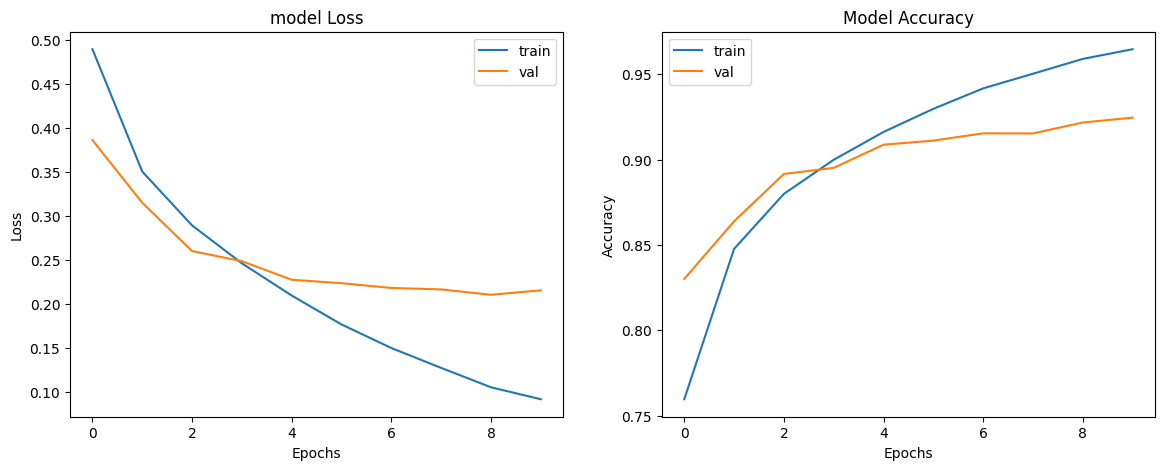

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()

# Confusion Matrix:

In [ ]:
y_pred = model.predict(test_generator)

y_test = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step


In [ ]:
y_pred_labels = np.argmax(y_pred, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred_labels)
confusion_matrix

array([[8977, 1023],
       [ 608, 9392]])

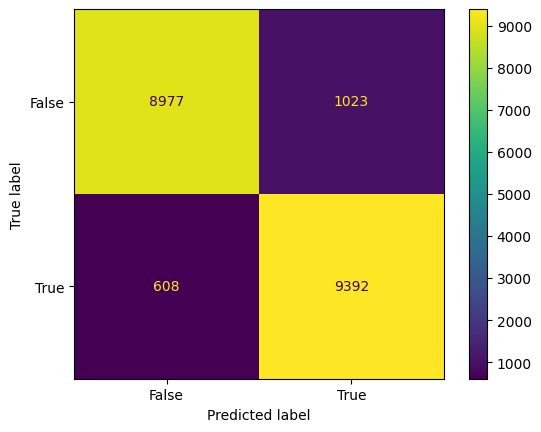

In [ ]:
from sklearn import metrics

Fake = False
Real = True
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix, display_labels=[Fake, Real]
)

cm_display.plot()
plt.show()

# ROC AUC Score, Precision Score and Test Accuracy:

In [ ]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_labels))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_labels))
print()
print(metrics.classification_report(y_test, y_pred_labels))

ROC AUC Score: 0.91845
AP Score: 0.8773482861257801

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     10000
           1       0.90      0.94      0.92     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



In [ ]:
_, accu, _, _ = model.evaluate(test_generator)
print("Final Test Acccuracy = {:.3f}".format(accu * 100))

625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9184 - loss: 0.2317 - precision: 0.9184 - recall: 0.9184
Final Test Acccuracy = 91.845


# Testing for a random image:

In [ ]:
from PIL import Image

im1 = Image.open(os.path.join(base_path, "Test", "real", "00001.jpg"))
im2 = im1.resize((224, 224))
p1 = np.array(im2)
p1 = np.array(im2) / 255.0
p1 = np.expand_dims(p1, axis=0)
p1.shape

(1, 224, 224, 3)

In [ ]:
op = np.argmax(model.predict(p1), axis=-1)
print(op)
if op == [0]:
    print("Fake Face")
else:
    print("Real Face")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step
[1]
Real Face
